<a href="https://colab.research.google.com/github/mel3883/Resumenes/blob/main/Herramientas_Labo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from math import floor, log10
import pandas as pd
import os
from scipy.integrate import quad
from scipy.stats import norm
from scipy.optimize import curve_fit
from io import StringIO
import glob

# **Referencias**

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html ➞ Referencias para graficar

https://numpy.org/doc/stable/user/absolute_beginners.html#plotting-arrays-with-matplotlib ➞ Referencias para NumPy

https://docs.scipy.org/doc/scipy/tutorial/ ➞ Referencias para Scipy

https://pandas.pydata.org/docs/getting_started/intro_tutorials/ ➞ Referencias para Pandas

https://github.com/mel3883/talleresfifabsas_mine/tree/da37d6f32f24bbe3a8f08b9bd7841552fbff1ac9/python ➞ FIFA's repository

# **Basicos**

popt = Parámetros Óptimos

pcov = Covarianza de los Parámetros

In [ ]:
#f"Data sin unpack:\n {data}". El \n te lo imprime con un enter

In [ ]:
###SUBIR ARCHIVOS

# Para leerlo (una columna por magnitud, separadas por espacios o comas):

# datos = np.loadtxt('mis_datos.txt')
# x, y = datos[:, 0], datos[:, 1]

#Para cambiar coma por punto:


In [93]:
datos = open('/content/sample_data/mine/mediciones.txt').read().replace(',','.')  #me reeemplaza las comas de un archivo por puntos
datos = np.loadtxt(StringIO(datos), skiprows = 2)


Fuerza = datos[:,0] #columna 1
median = datos[:,1] #columna 2
std_dev = datos[:,2] #columna 3
alargamiento = datos[:,3] #columna 4

print(f'Fuerza :\n {Fuerza}', f'\n', f'\n', f'Mediana :\n {median}',f'\n', f'\n',
      f'Deviacion estandar :\n {std_dev}', f'\n', f'\n', f'Alargamiento del resorte :\n {alargamiento}')

Fuerza :
 [0.97902  0.489706 0.09653  1.467942 0.43953  0.978628 1.957648 0.14553
 0.782138 1.124158 1.12455  1.319766 1.514688 1.906296 1.710492] 
 
 Mediana :
 [2.546105 2.620961 2.735827 2.400264 2.686783 2.635158 2.393165 2.507386
 2.560947 2.471248 2.391875 2.342185 2.220866 2.162143 2.212477] 
 
 Deviacion estandar :
 [0.007273 0.004208 0.052416 0.005849 0.036034 0.015375 0.00716  0.003279
 0.032246 0.009283 0.017483 0.007024 0.035873 0.006833 0.002316] 
 
 Alargamiento del resorte :
 [35.2 33.3 32.  36.5 33.8 34.3 38.1 32.3 34.2 35.3 34.9 36.3 36.7 37.6
 37.3]


In [ ]:
###FIFA's info

# data = np.loadtxt('nombre_del_archivo.csv', delimiter=',', skiprows=1, unpack=True)

#El primer argumento es ubicación del archivo con la ruta respecto del archivo de Python.
#El segundo argumento, delimiter, recibe un string que le indica a Python cómo están separados los valores en nuestro archivo.
#El tercer argumento es nos permite evitar que Python lea algunas lineas del archivo.
#Por qué unpack=True?
#np.loadtxt() por defecto te da los valores exactamente como están en el CSV/TXT, por lo que en este caso nos daría 2 columnas de datos con 20 filas.
#Utilizando unpack=True trasponemos los datos para pasar las columnas a filas.
#También podríamos importarlo sin usar el unpack=True y luego usar data = np.transpose(data)


In [107]:
data2 = np.loadtxt('/content/sample_data/mine/Serie A.txt', delimiter=',', skiprows=1, unpack = True)

print(data2)

print()
data3 = np.transpose(data2)

print(data3)                                                                #lol? welll anyways

[1.13 1.13 1.   1.23 1.07 1.26 1.16 1.08 1.21 1.3  0.98 0.92 1.12 1.13
 1.11 1.05 1.07 1.07 0.98 0.99 1.15 1.11 1.33 1.15 1.12 1.16 1.32 1.25
 1.26 0.94 1.38 1.48 0.93 1.   0.95 0.99 1.   1.05 1.   1.14 1.13 1.12
 0.93 1.14 1.05 1.13 1.06 1.05 1.   1.11]

[1.13 1.13 1.   1.23 1.07 1.26 1.16 1.08 1.21 1.3  0.98 0.92 1.12 1.13
 1.11 1.05 1.07 1.07 0.98 0.99 1.15 1.11 1.33 1.15 1.12 1.16 1.32 1.25
 1.26 0.94 1.38 1.48 0.93 1.   0.95 0.99 1.   1.05 1.   1.14 1.13 1.12
 0.93 1.14 1.05 1.13 1.06 1.05 1.   1.11]


# **Pandas tools**

In [112]:
df = pd.read_csv('/content/sample_data/mine/mediciones.txt')     #Ok quedo mal pero se entiende la idea del uso

display(df)

Fuerza (F)    median    std.dev   largo con el peso (cm)
0 979020      2 546105  0 007273  35                                                  2.0       
  489706      2 620961  0 004208  33                                                  3.0       
  096530      2 735827  0 052416  32                                                  0.0       
1 467942      2 400264  0 005849  36                                                  5.0       
0 439530      2 686783  0 036034  33                                                  8.0       
  978628      2 635158  0 015375  34                                                  3.0       
1 957648      2 393165  0 007160  38.1                                                NaN       
0 145530      2 507386  0 003279  32                                                  3.0       
  782138      2 560947  0 032246  34                                                  2.0       
1 124158      2 471248  0 009283  35                                                  3.0       
  124550      2 391875  0 017483  34                                                  9.0       
  319766      2 342185  0 007024  36                                                  3.0       
  514688      2 220866  0 035873  36                                                  7.0       
  906296      2 162143  0 006833  37                                                  6.0       
  710492      2 212477  0 002316  37                                                  3.0

# **TBD**

In [6]:
###ERROR DE CERO, CORRECCION

error_cero = 0.10                                                 # El error en mm
lecturas_crudas = np.array([12.80, 12.85, 12.75, 12.80, 12.85])   # Datos en mm

lecturas = lecturas_crudas - error_cero

print("crudas    :", lecturas_crudas)
print("corregidas:", np.round(lecturas, 3))
print()
print(f"promedio crudo      : {lecturas_crudas.mean():.3f} mm")
print(f"promedio corregido  : {lecturas.mean():.3f} mm")
print(f"la diferencia es exactamente el error de cero: {error_cero} mm")

crudas    : [12.8  12.85 12.75 12.8  12.85]
corregidas: [12.7  12.75 12.65 12.7  12.75]

promedio crudo      : 12.810 mm
promedio corregido  : 12.710 mm
la diferencia es exactamente el error de cero: 0.1 mm


# **Reportar:** Valores

In [57]:
###REDONDEAR CUANDO LA CIFRA EMPIEZA CON 1 O 2

def redondear_con_error(x, dx, dos_cifras_si_empieza_en_1_o_2=True):
    '''
    Devuelve (valor, error, n_decimales) redondeados según la regla estándar.
    '''
    if dx <= 0:
        raise ValueError("La incerteza debe ser positiva.")
    orden   = floor(log10(abs(dx)))
    primera = int(dx / 10**orden)
    cifras  = 2 if (dos_cifras_si_empieza_en_1_o_2 and primera in (1, 2)) else 1
    dec     = -(orden - (cifras - 1))
    return round(x, dec), round(dx, dec), max(dec, 0)

###REPORTAR EL VALOR CON EL ERROR YA REDONDEADO CORRECTAMENTE

def reportar(x, dx, unidad=""):
    '''
    Devuelve el string '(valor ± error) unidad' con las cifras correctas.
    '''
    x_r, dx_r, dec = redondear_con_error(x, dx)
    return f"({x_r:.{dec}f} ± {dx_r:.{dec}f}) {unidad}".strip()

In [66]:
###EJEMPLOS SOLO DE REDONDEO
A = redondear_con_error(7.47, 0.156, dos_cifras_si_empieza_en_1_o_2=True)
B = redondear_con_error(7.47, 0.386, dos_cifras_si_empieza_en_1_o_2=True)

print()
print(f'Ejemplo solo usando funcion redondear_con_cero:')
print(f'A = ', A)
print(f'B = ', B)


###EJEMPLOS DE REPORTAR
C = reportar(7.47, 0.156, unidad="tuki")
D = reportar(7.47, 0.386, unidad="tuki")

print()
print(f'Ejemplo solo usando funcion reportar:')
print(f'C = ', C)
print(f'D = ', D)


Ejemplo solo usando funcion redondear_con_cero:
A =  (7.47, 0.16, 2)
B =  (7.5, 0.4, 1)

Ejemplo solo usando funcion reportar:
C =  (7.47 ± 0.16) tuki
D =  (7.5 ± 0.4) tuki


Promedio:

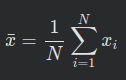

El promedio es un estimador de μ, y bajo tres supuestos es el mejor disponible:

1. los errores son puramente aleatorios (no hay sesgo sistemático);
2. las mediciones son independientes entre sí;
3. la distribución tiene varianza finita.2.



In [118]:
t = np.array([2,5,9,12,4,17,19,2])  #Sumados me dan 70. Dividido por 8: 8.75

N = len(t)
promedio = np.mean(t)
print(f"np.mean  : {promedio:.6f} s")
print(f"suma / N : {np.sum(t)/N:.6f} s")
print(f"N = {N}")

np.mean  : 8.750000 s
suma / N : 8.750000 s
N = 8


Desviacion estandar **muestral**:

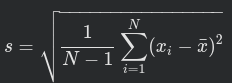



In [119]:
s_mal  = np.std(t)              # ddof=0 por defecto  -> POBLACIONAL (incorrecto acá)
s_bien = np.std(t, ddof=1)      # muestral            -> correcto

print(f"np.std(t)          = {s_mal:.6f} s   <- NO usar")
print(f"np.std(t, ddof=1)  = {s_bien:.6f} s   <- usar ésta")
print(f"diferencia relativa: {100*(s_bien-s_mal)/s_bien:.3f} %")
print()
for n in [3, 5, 10, 30, 100, 1000]:
    factor = np.sqrt(n / (n - 1))
    print(f"N = {n:5d}  ->  s_muestral / s_poblacional = {factor:.4f}"
          f"   ({100*(factor-1):5.2f} % de subestimación si te olvidás)")

np.std(t)          = 6.239992 s   <- NO usar
np.std(t, ddof=1)  = 6.670832 s   <- usar ésta
diferencia relativa: 6.459 %

N =     3  ->  s_muestral / s_poblacional = 1.2247   (22.47 % de subestimación si te olvidás)
N =     5  ->  s_muestral / s_poblacional = 1.1180   (11.80 % de subestimación si te olvidás)
N =    10  ->  s_muestral / s_poblacional = 1.0541   ( 5.41 % de subestimación si te olvidás)
N =    30  ->  s_muestral / s_poblacional = 1.0171   ( 1.71 % de subestimación si te olvidás)
N =   100  ->  s_muestral / s_poblacional = 1.0050   ( 0.50 % de subestimación si te olvidás)
N =  1000  ->  s_muestral / s_poblacional = 1.0005   ( 0.05 % de subestimación si te olvidás)


# **Reportar:** Graficos

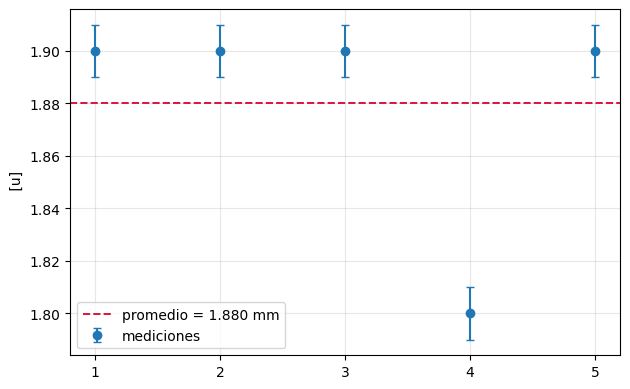

In [27]:
# Las mediciones del grupo, una por integrante, con el mismo instrumento
integrante = np.array([1, 2, 3, 4, 5])        # Divisiones de abajo
valor      = medidas["regla      (Δ = 1 mm)"] # This long ass space is relevant for some reason
err        = np.full_like(valor, 0.01)        # Resolución del micrómetro

fig, ax = plt.subplots(figsize=(6.4, 4))      # El figsize te alarga o achica la longitud o altura de la imagen (long, altura)
ax.errorbar(integrante, valor, yerr=err, fmt='o', capsize=3, label='mediciones')
ax.axhline(valor.mean(), color='crimson', ls='--', lw=1.4,
           label=f'promedio = {valor.mean():.3f} mm')
ax.set_xlabel('')
ax.set_ylabel(' [u]')
ax.set_title('')
ax.set_xticks(integrante)
ax.grid(alpha=0.3); ax.legend()              # El alpha va entre 0 y 1 y es la transparencia de las lineas del grid
fig.tight_layout(); plt.show()

In [20]:
###PARA GUARDAR GRAFICOS

#fig.savefig('Nombre.pdf', bbox_inches='tight')             # PDF: vectorial, no pixela
#fig.savefig('Nombre.png', dpi=200, bbox_inches='tight')

##Si lo ejecutas te va a tirar error porque no hay tal grafico

# **Propagar**

In [18]:
###DETERMINAR DISPERSION O RESOLUCION

medidas = {
    "regla      (Δ = 1 mm)":    np.array([1.9, 1.9, 1.9, 1.8, 1.9]),        #Instrumentos usados con los datos
    "calibre    (Δ = 0,02 mm)": np.array([150.38, 150.34,150.20, 150.18]),
    "micrómetro (Δ = 0,01 mm)": np.array([12.62, 12.61,12.62, 12.58]),
}

resoluciones = [1.0, 0.02, 0.01]

# Parte del titulo

print(f"{'Instrumento':26s} {'promedio':>10s} {'dispersión':>12s} "
      f"{'resolución':>12s} {'manda':>12s}")
print("-" * 76)
for (nombre, x), delta in zip(medidas.items(), resoluciones):
    disp = np.std(x, ddof=1)
    manda = "dispersión" if disp > delta else "resolución"

# Actual cuentas

print(f"{nombre:26s} {x.mean():10.4f} {disp:12.4f} {delta:12.4f} {manda:>12s}")



Instrumento                  promedio   dispersión   resolución        manda
----------------------------------------------------------------------------
micrómetro (Δ = 0,01 mm)      12.6075       0.0189       0.0100   dispersión


In [28]:
###PROPAGAR INCERTEZAS + CONTRIBUCIONES

def propagar(expr, variables, valores, errores, nombre='f'):
    '''
    Propaga incertezas de una expresión simbólica e imprime la tabla de contribuciones.

    expr      : expresión de SymPy
    variables : lista de símbolos
    valores   : dict {símbolo: valor medido}
    errores   : dict {símbolo: incerteza}
    Devuelve (valor, incerteza).
    '''

    valor = float(expr.subs(valores))
    contribuciones = {}
    for v in variables:
        d = float(sp.diff(expr, v).subs(valores))
        contribuciones[v] = (d * errores[v])**2
    var_total = sum(contribuciones.values())
    sigma = np.sqrt(var_total)

    print(f"{nombre} = {valor:.6g}  ±  {sigma:.3g}      "
          f"(error relativo: {100*sigma/abs(valor):.2f} %)")
    print()
    print(f"{'variable':>10s} {'valor':>12s} {'σ':>12s} {'σ rel.':>9s} "
          f"{'contrib. a σ²':>15s}")
    print("-" * 64)
    for v in variables:
        frac = contribuciones[v] / var_total
        print(f"{str(v):>10s} {float(valores[v]):12.6g} {errores[v]:12.3g} "
              f"{100*errores[v]/float(valores[v]):8.2f}% {100*frac:14.1f}%")
    return valor, sigma

In [33]:
###EJEMPLO DE SU USO

# Primero defini las variables simbólicas. El positive = true es para que que Python entienda que es positivo y no genere problemas al derivar
m, D, h = sp.symbols('m D h', positive = True)

# Despues defini la expresión simbólica para la magnitud con su nombre asignado, en este ejemplo: densidad (rho)
rho = 4*m / (sp.pi * D**2 * h)

# Defini los valores medidos y sus errores
ejemplo_valores = {m: 0.100, D: 0.020, h: 0.050}  # masa en kg, diámetro en m, altura en m
ejemplo_errores = {m: 0.001, D: 0.0005, h: 0.001} # errores correspondientes

# Usa la funcion. El primer item de los dos antes del giaul sera el promedio, y el segundo su error
ejemplo_rho_val, ejemplo_rho_err = propagar(rho, [m, D, h], ejemplo_valores, ejemplo_errores, nombre = 'Densidad [kg/m³]')

print('\n--- Resultado reportado ---')
print("reportar(ejemplo_rho_val, ejemplo_rho_err, 'kg/m³')")



Densidad [kg/m³] = 6366.2  ±  349      (error relativo: 5.48 %)

  variable        valor            σ    σ rel.   contrib. a σ²
----------------------------------------------------------------
         m          0.1        0.001     1.00%            3.3%
         D         0.02       0.0005     2.50%           83.3%
         h         0.05        0.001     2.00%           13.3%

--- Resultado reportado ---
reportar(ejemplo_rho_val, ejemplo_rho_err, 'kg/m³')


In [34]:
###PROPAGAR SOBRE COLUMNAS DE DATOS, LAMBDIFY: SymPy creates a function analogous to f

#Cuando tenés que propagar sobre una columna entera de datos usamos lambdify
#para convertir la expresión simbólica en una función de NumPy. Ejemplo de uso:


# Definimos variables simbólicas para masa (m) y velocidad (v). Si pudieran ser negativas no poner el positive = True
m_k, v_k = sp.symbols('m_k v_k', positive = True)

# Definimos la expresión para la energía cinética; la funcion f
energia_cinetica = sp.Rational(1, 2) * m_k * v_k**2

print(f"Expresión de energía cinética: K = {energia_cinetica}")

# Definimos los símbolos para las incertezas de masa y velocidad
sig_mk, sig_vk = sp.symbols('sigma_mk sigma_vk', positive = True)

# Calculamos la varianza propagada para la energía cinética
var_energia_cinetica = (
    (sp.diff(energia_cinetica, m_k))**2 * sig_mk**2 +
    (sp.diff(energia_cinetica, v_k))**2 * sig_vk**2
)
sigma_energia_cinetica = sp.sqrt(var_energia_cinetica)

print(f"Incerteza propagada de energía cinética: σ_K = {sigma_energia_cinetica}")

# Creamos funciones de Python usando lambdify. (variables, funcion, *)
#* = El 'numpy' le indica que use las funciones de NumPy, lo que permite pasarle arrays como entrada y obtener arreglos como salida.
# La f_energia_cinetica va a saber que debe recibir dos arrays de 'variables', y aplicarlas a la funcion definida como energia_cinetica
# En el caso de la otra sabe que recibe 4 arrays
f_energia_cinetica = sp.lambdify((m_k, v_k), energia_cinetica, 'numpy')
f_sigma_energia_cinetica = sp.lambdify((m_k, v_k, sig_mk, sig_vk), sigma_energia_cinetica, 'numpy')

# Proporcionamos algunos valores de ejemplo (como arrays para demostrar la vectorialización)
masas_ej = np.array([1.0, 2.0, 0.5])        # kg
velocidades_ej = np.array([5.0, 3.0, 10.0]) # m/s

# Incertezas para los valores de ejemplo
sig_masas_ej = np.array([0.01, 0.02, 0.005])    # kg
sig_velocidades_ej = np.array([0.1, 0.05, 0.2]) # m/s

# Calculamos la energía cinética y su incerteza para cada conjunto de valores
# Aca vemos que la de arriba toma 2 variables, y la de abajo 4
k_vals = f_energia_cinetica(masas_ej, velocidades_ej)
sig_k_vals = f_sigma_energia_cinetica(masas_ej, velocidades_ej, sig_masas_ej, sig_velocidades_ej)

print("\nResultados de Energía Cinética con incerteza:")
for i in range(len(masas_ej)):
    print(f"Objeto {i+1}: K = {k_vals[i]:.2f} ± {sig_k_vals[i]:.2f} Joules")     #:.2f es un especificador de formato que le dice a Python cómo debe mostrar ese número.
                                                                                 #Significa:  :) Inicia la especificación de formato.
                                                                                 #           .2) Redondea el número a dos decimales.
                                                                                 #            f) Trata el número como un punto flotante (número decimal).


Expresión de energía cinética: K = m_k*v_k**2/2
Incerteza propagada de energía cinética: σ_K = sqrt(m_k**2*sigma_vk**2*v_k**2 + sigma_mk**2*v_k**4/4)

Resultados de Energía Cinética con incerteza:
Objeto 1: K = 12.50 ± 0.52 Joules
Objeto 2: K = 9.00 ± 0.31 Joules
Objeto 3: K = 25.00 ± 1.03 Joules
